In [8]:
import pandas as pd

df = pd.read_csv(
    "rows.csv",
    engine="python",
    on_bad_lines="skip",
    nrows=50000
)

print(df.shape)

(50000, 18)


In [9]:
print(df.columns)

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')


In [10]:
print(df['Consumer complaint narrative'].isnull().sum())

47354


In [11]:
nlp_df = df[['Consumer complaint narrative', 'Product']].copy()

nlp_df = nlp_df.dropna()

print("Shape after removing nulls:", nlp_df.shape)

nlp_df.head()


Shape after removing nulls: (2646, 2)


,Consumer complaint narrative,Product
29904,The Summer of XX/XX/2018 I was denied a mortga...,"Credit reporting, credit repair services, or o..."
30629,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."
30735,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."
30795,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."
30807,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."


In [12]:
top_products = nlp_df['Product'].value_counts().head(5).index

nlp_df = nlp_df[nlp_df['Product'].isin(top_products)]

print(nlp_df['Product'].value_counts())

Product
Credit reporting, credit repair services, or other personal consumer reports    1100
Debt collection                                                                  720
Credit card or prepaid card                                                      228
Mortgage                                                                         190
Student loan                                                                     138
Name: count, dtype: int64


In [13]:
import re
import string

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    return text.strip()

nlp_df['Cleaned_Text'] = nlp_df['Consumer complaint narrative'].apply(clean_text)

nlp_df[['Consumer complaint narrative', 'Cleaned_Text']].head()

,Consumer complaint narrative,Cleaned_Text
29904,The Summer of XX/XX/2018 I was denied a mortga...,the summer of xxxx i was denied a mortgage loa...
30629,There are many mistakes appear in my report wi...,there are many mistakes appear in my report wi...
30735,There are many mistakes appear in my report wi...,there are many mistakes appear in my report wi...
30795,There are many mistakes appear in my report wi...,there are many mistakes appear in my report wi...
30807,There are many mistakes appear in my report wi...,there are many mistakes appear in my report wi...


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(nlp_df['Cleaned_Text'])

y = nlp_df['Product']

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (2376, 5000)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (1900, 5000)
Test : (476, 5000)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [17]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8172268907563025

Classification Report:

                                                                              precision    recall  f1-score   support

                                                 Credit card or prepaid card       0.87      0.72      0.79        46
Credit reporting, credit repair services, or other personal consumer reports       0.80      0.89      0.84       220
                                                             Debt collection       0.80      0.81      0.80       144
                                                                    Mortgage       0.94      0.76      0.84        38
                                                                Student loan       0.94      0.57      0.71        28

                                                                    accuracy                           0.82       476
                                                                   macro avg       0.87      0.75      0.80       476


In [18]:
def predict_complaint(text):

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)

    return prediction[0]

In [19]:
sample = """
I was denied a mortgage loan even though my credit score is good.
"""

print("Predicted Category:")
print(predict_complaint(sample))

Predicted Category:
Mortgage


In [20]:
import pickle

pickle.dump(model, open("ticket_classifier.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


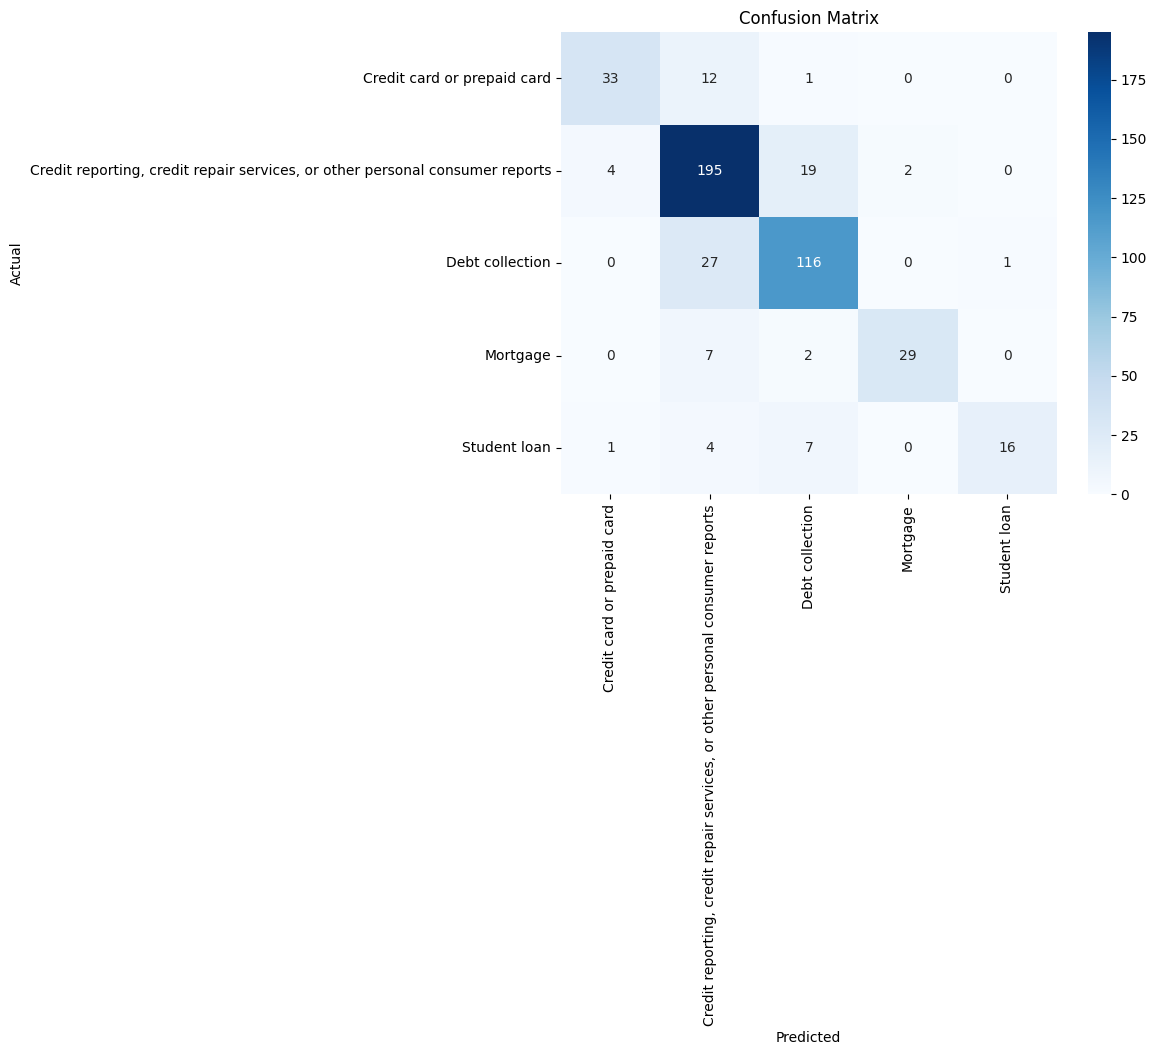

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()